# 🧠 Brain Tumor Classification — VS Code Notebook

**CPU-optimised:** 96×96 images · lightweight models · tf.data caching  
Expected training time: **~3–5 min per model on CPU**  

| Setting | CPU mode | GPU mode |
|---|---|---|
| Image size | 96×96 | 224×224 |
| CNN filters | 32-64-128 | 32-64-128-256 |
| MobileNetV2 alpha | 0.35 | 1.0 |
| Epochs | 20 | 30 |

To switch to GPU mode: open `brain_tumor_classification.py` and set `USE_GPU_SETTINGS = True`

### Folder structure
```
project_root/
├── brain_tumor_classification.py
├── brain_tumor_notebook.ipynb   ← this file
├── data/
│   ├── Training/  glioma/ meningioma/ notumor/ pituitary/
│   └── Testing/   glioma/ meningioma/ notumor/ pituitary/
└── outputs/                     ← auto-created
```

In [2]:
# ── Cell 1 : Install packages (run once, then restart kernel) ────────────────
import subprocess, sys
pkgs = ['tensorflow', 'opencv-python', 'scikit-learn', 'seaborn', 'matplotlib', 'streamlit']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('✓ All packages installed — restart kernel if this was your first install')

✓ All packages installed — restart kernel if this was your first install


In [3]:
# ── Cell 2 : Import pipeline ─────────────────────────────────────────────────
import importlib
import brain_tumor_classification as btc
importlib.reload(btc)

from brain_tumor_classification import (
    cfg, USE_GPU_SETTINGS, setup, build_datasets, visualise_samples,
    build_custom_cnn, build_lenet, build_mobilenet,
    compile_model, train_model, unfreeze_for_finetuning,
    evaluate_model, plot_confusion_matrix, plot_training_curves,
    compare_models, show_sample_predictions, visualise_gradcam,
    predict_single_image, save_streamlit_app,
)
print(f'Mode: {"GPU" if USE_GPU_SETTINGS else "CPU-optimised"}  |  Image size: {cfg.IMG_SIZE}')

Mode: CPU-optimised  |  Image size: (96, 96)


In [3]:
# ── Cell 3 : Setup — verify paths, GPU, expected time ────────────────────────
setup()

  Brain Tumor Classification — Environment
  Root       : C:\--Files--\Programming\Projects\Tumor-Detection
  TensorFlow : 2.19.0
  GPU        : None — CPU only
  Image size : (96, 96)  (CPU-optimised)
  Batch size : 32
  Epochs     : 20
  MN alpha   : 0.35
  Output dir : C:\--Files--\Programming\Projects\Tumor-Detection\outputs
  Training: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1400, 'pituitary': 1400}
  Testing : {'glioma': 400, 'meningioma': 400, 'notumor': 400, 'pituitary': 400}


True


[Data]  Train : 4480  |  Val : 1120  |  Test : 1600
        Batches/epoch (train): 140
        Class weights : {'glioma': np.float64(0.982), 'meningioma': np.float64(0.996), 'notumor': np.float64(1.018), 'pituitary': np.float64(1.004)}
    [✓] outputs/sample_images.png


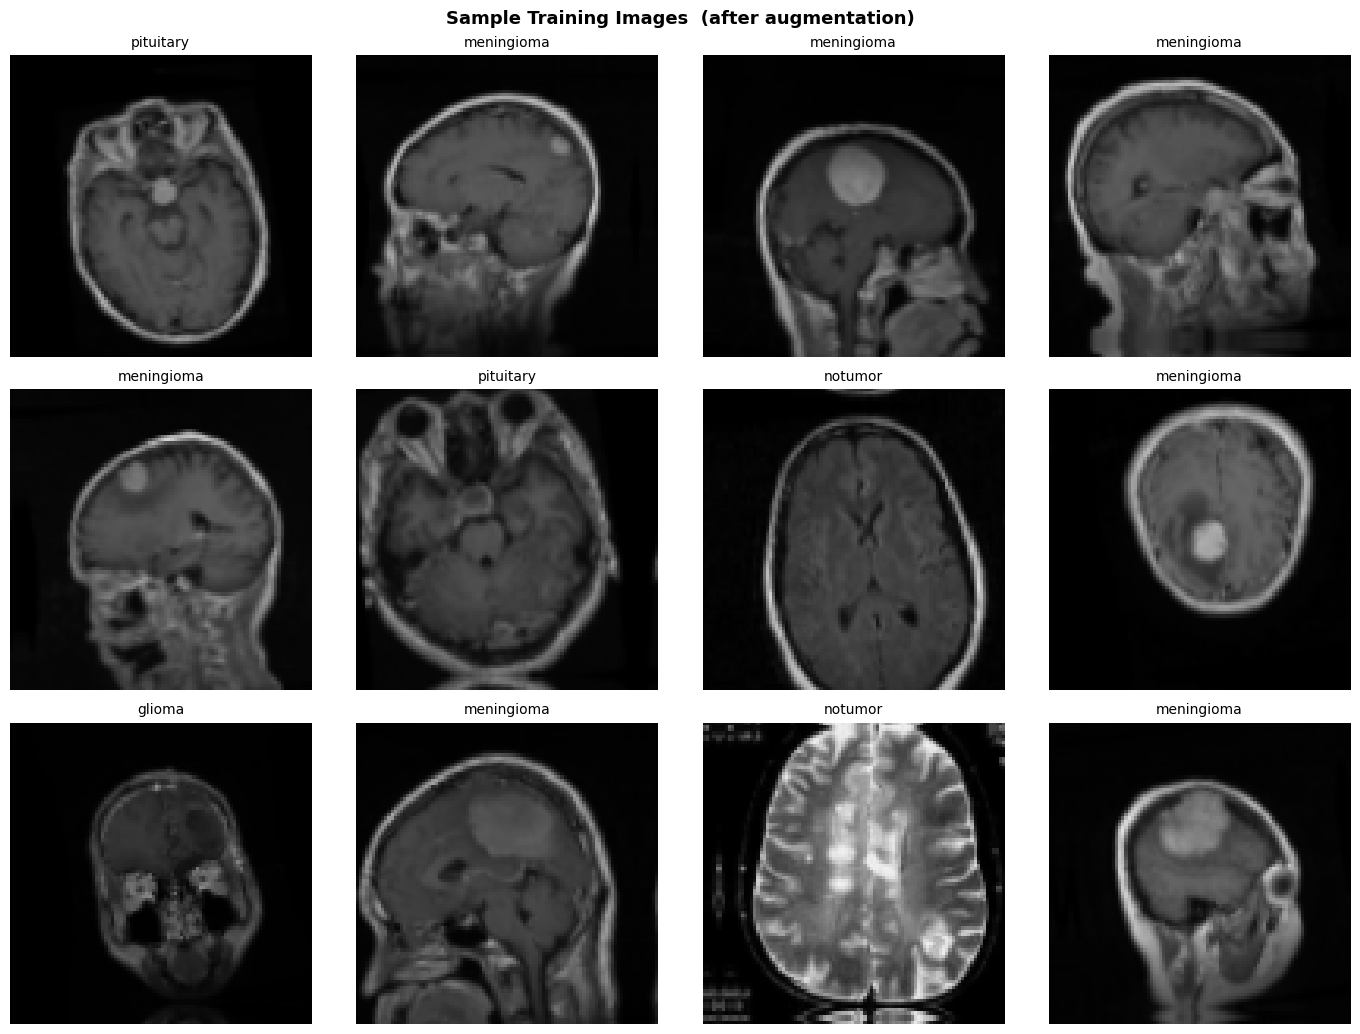

In [4]:
# ── Cell 4 : Build tf.data datasets ─────────────────────────────────────────
# tf.data is used instead of ImageDataGenerator for ~3× faster CPU throughput.
# Images are cached in RAM after the first epoch — subsequent epochs are instant.
(
    train_ds, val_ds, test_ds,
    class_weights, tr_labels,
    n_train, n_val, n_test,
    test_paths, test_labels
) = build_datasets()

visualise_samples(train_ds)

---
## Model 1 — Custom CNN
3 conv blocks (32→64→128) · BatchNorm · Dropout · GAP head  
⏱ Expected: **~3–5 min on CPU** at 96×96

In [5]:
# ── Cell 5 : Build CNN ───────────────────────────────────────────────────────
cnn = compile_model(build_custom_cnn())
cnn.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c1 (Conv2D)                  │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_c2 (Conv2D)                  │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn (BatchNormalization)      │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_drop (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c1 (Conv2D)                  │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_c2 (Conv2D)                  │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn (BatchNormalization)      │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_drop (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c1 (Conv2D)                  │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_c2 (Conv2D)                  │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn (BatchNormalization)      │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pool (MaxPooling2D)          │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_drop (Dropout)               │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_gap                         │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_bn (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_fc1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_drop1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_fc2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_drop2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_out (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,444 (1.20 MB)

 Trainable params: 312,740 (1.19 MB)

 Non-trainable params: 704 (2.75 KB)

In [6]:
# ── Cell 6 : Train CNN ───────────────────────────────────────────────────────
# Speed estimate prints before training begins.
h_cnn, ckpt_cnn = train_model(cnn, 'CustomCNN',
                               train_ds, val_ds, class_weights)


════════════════════════════════════════════════════════
  Training  →  CustomCNN  (313,444 params)
  Image size: (96, 96)  |  Epochs: 20  |  Batch: 32
════════════════════════════════════════════════════════
  [⏱]  Estimating training speed … 1.65s/batch → ~3.8 min/epoch
  → Estimated total training time: ~77 min (early stopping may cut this short)
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.5599 - auc: 0.7940 - loss: 1.1529 - precision: 0.6690 - recall: 0.4091

140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 269ms/step - accuracy: 0.5602 - auc: 0.7943 - loss: 1.1519 - precision: 0.6693 - recall: 0.4095 - val_accuracy: 0.2545 - val_auc: 0.5107 - val_loss: 2.1617 - val_precision: 0.2545 - val_recall: 0.2545 - learning_rate: 0.0010
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - accuracy: 0.6714 - auc: 0.8867 - loss: 0.8356 - precision: 0.7306 - recall: 0.5855 - val_accuracy: 0.2545 - val_auc: 0.5814 - val_loss: 2.8453 - val_precision: 0.2545 - val_recall: 0.2545 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7261 - auc: 0.9133 - loss: 0.7338 - precision: 0.7778 - recall: 0.6530

140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 389ms/step - accuracy: 0.7261 - auc: 0.9133 - loss: 0.7337 - precision: 0.7777 - recall: 0.6530 - val_accuracy: 0.5473 - val_auc: 0.8233 - val_loss: 1.0477 - val_precision: 0.6833 - val_recall: 0.5009 - learning_rate: 0.0010
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.7533 - auc: 0.9274 - loss: 0.6667 - precision: 0.7929 - recall: 0.6850

140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 346ms/step - accuracy: 0.7534 - auc: 0.9274 - loss: 0.6666 - precision: 0.7930 - recall: 0.6851 - val_accuracy: 0.6321 - val_auc: 0.8617 - val_loss: 0.9996 - val_precision: 0.6612 - val_recall: 0.5732 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 260ms/step - accuracy: 0.7863 - auc: 0.9422 - loss: 0.5985 - precision: 0.8175 - recall: 0.7406 - val_accuracy: 0.3027 - val_auc: 0.5950 - val_loss: 5.3576 - val_precision: 0.3023 - val_recall: 0.2991 - learning_rate: 0.0010
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 262ms/step - accuracy: 0.7873 - auc: 0.9446 - loss: 0.5837 - precision: 0.8171 - recall: 0.7433 - val_accuracy: 0.6250 - val_auc: 0.8862 - val_loss: 0.8983 - val_precision: 0.6688 - val_recall: 0.5696 - learning_rate: 0.0010
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.8210 - auc: 0.9587 - loss: 0.5039 - precision: 0.8489 - recall: 0.7923 - val_accuracy: 0.6196 - val_auc: 0.8579 - val_loss: 1.1875 - va

140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 264ms/step - accuracy: 0.8494 - auc: 0.9717 - loss: 0.4149 - precision: 0.8782 - recall: 0.8250 - val_accuracy: 0.8054 - val_auc: 0.9584 - val_loss: 0.5271 - val_precision: 0.8239 - val_recall: 0.7768 - learning_rate: 5.0000e-04
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 275ms/step - accuracy: 0.8653 - auc: 0.9776 - loss: 0.3720 - precision: 0.8834 - recall: 0.8437 - val_accuracy: 0.7554 - val_auc: 0.9247 - val_loss: 0.7161 - val_precision: 0.7800 - val_recall: 0.7188 - learning_rate: 5.0000e-04
Epoch 11/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.8656 - auc: 0.9782 - loss: 0.3664 - precision: 0.8874 - recall: 0.8473

140/140 ━━━━━━━━━━━━━━━━━━━━ 68s 483ms/step - accuracy: 0.8656 - auc: 0.9782 - loss: 0.3664 - precision: 0.8874 - recall: 0.8473 - val_accuracy: 0.8357 - val_auc: 0.9715 - val_loss: 0.4152 - val_precision: 0.8571 - val_recall: 0.8250 - learning_rate: 5.0000e-04
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.8805 - auc: 0.9822 - loss: 0.3336 - precision: 0.8957 - recall: 0.8653 - val_accuracy: 0.6179 - val_auc: 0.8699 - val_loss: 1.0462 - val_precision: 0.6360 - val_recall: 0.5866 - learning_rate: 5.0000e-04
Epoch 13/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8994 - auc: 0.9853 - loss: 0.3034 - precision: 0.9144 - recall: 0.8837

140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.8993 - auc: 0.9853 - loss: 0.3036 - precision: 0.9143 - recall: 0.8837 - val_accuracy: 0.8813 - val_auc: 0.9817 - val_loss: 0.3387 - val_precision: 0.8903 - val_recall: 0.8696 - learning_rate: 5.0000e-04
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 267ms/step - accuracy: 0.8885 - auc: 0.9839 - loss: 0.3155 - precision: 0.9048 - recall: 0.8766 - val_accuracy: 0.8482 - val_auc: 0.9735 - val_loss: 0.4058 - val_precision: 0.8743 - val_recall: 0.8134 - learning_rate: 5.0000e-04
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9033 - auc: 0.9868 - loss: 0.2857 - precision: 0.9144 - recall: 0.8874
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 278ms/step - accuracy: 0.9032 - auc: 0.9868 - loss: 0.2858 - precision: 0.9144 - recall: 0.8874 - val_accuracy: 0.8071 - val_auc: 0.9649 - val_loss: 0.4877 - val_precision: 0.8308 - val_recall: 0.7937 - learning_ra

140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 274ms/step - accuracy: 0.9068 - auc: 0.9888 - loss: 0.2676 - precision: 0.9184 - recall: 0.8950 - val_accuracy: 0.9080 - val_auc: 0.9866 - val_loss: 0.2701 - val_precision: 0.9141 - val_recall: 0.9027 - learning_rate: 2.5000e-04
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.9187 - auc: 0.9900 - loss: 0.2442 - precision: 0.9299 - recall: 0.9089 - val_accuracy: 0.8446 - val_auc: 0.9743 - val_loss: 0.4151 - val_precision: 0.8669 - val_recall: 0.8375 - learning_rate: 2.5000e-04
Epoch 18/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9226 - auc: 0.9917 - loss: 0.2285 - precision: 0.9333 - recall: 0.9112
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 266ms/step - accuracy: 0.9225 - auc: 0.9917 - loss: 0.2287 - precision: 0.9333 - recall: 0.9112 - val_accuracy: 0.8464 - val_auc: 0.9749 - val_loss: 0.4132 - val_precision: 0.8588 - val_recall: 0.8366 - learning_ra

140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 267ms/step - accuracy: 0.9194 - auc: 0.9915 - loss: 0.2328 - precision: 0.9288 - recall: 0.9126 - val_accuracy: 0.9330 - val_auc: 0.9912 - val_loss: 0.2108 - val_precision: 0.9387 - val_recall: 0.9295 - learning_rate: 1.2500e-04
Epoch 20/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 266ms/step - accuracy: 0.9306 - auc: 0.9930 - loss: 0.2115 - precision: 0.9363 - recall: 0.9185 - val_accuracy: 0.8929 - val_auc: 0.9843 - val_loss: 0.3126 - val_precision: 0.9056 - val_recall: 0.8821 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 19.

  ✓ Completed 20 epochs in 13.7 min
  ✓ Best val accuracy : 93.30%
  ✓ Checkpoint        : C:\--Files--\Programming\Projects\Tumor-Detection\outputs\best_CustomCNN.h5


In [27]:
# ── Cell 7 : Evaluate + visualise CNN ───────────────────────────────────────
metrics_cnn = evaluate_model(cnn, test_ds, 'CustomCNN')
plot_confusion_matrix(metrics_cnn, 'CustomCNN')
plot_training_curves(h_cnn, 'CustomCNN')
show_sample_predictions(cnn, test_ds, 'CustomCNN')
visualise_gradcam(cnn, test_ds, 'CustomCNN', n_samples=cfg.GRADCAM_SAMPLES)


[Evaluate]  CustomCNN …
  Metric keys : ['loss', 'compile_metrics']
  Accuracy   : 0.00%
  Precision  : 0.00%
  Recall     : 0.00%
  F1 (wgt)   : 85.92%

              precision    recall  f1-score   support

      glioma       0.99      0.65      0.79       400
  meningioma       0.82      0.81      0.82       400
     notumor       0.81      1.00      0.89       400
   pituitary       0.90      0.99      0.94       400

    accuracy                           0.86      1600
   macro avg       0.88      0.86      0.86      1600
weighted avg       0.88      0.86      0.86      1600

    [✓] outputs/cm_CustomCNN.png
    [✓] outputs/curves_CustomCNN.png
    [✓] outputs/predictions_CustomCNN.png

[Grad-CAM]  CustomCNN  (4 samples) …
  Layer: 'b3_c2'
    [✓] outputs/gradcam_CustomCNN.png


---
## Model 2 — LeNet-5
Classic LeNet adapted for colour MRI images.  
⏱ Expected: **~1–2 min on CPU** (very small model)

In [17]:
lenet = compile_model(build_lenet())
lenet.summary()

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lenet_input (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c1 (Conv2D)                     │ (None, 96, 96, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2 (AveragePooling2D)           │ (None, 48, 48, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 48, 48, 6)      │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c3 (Conv2D)                     │ (None, 44, 44, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s4 (AveragePooling2D)           │ (None, 22, 22, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 22, 22, 16)     │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c5 (Conv2D)                     │ (None, 18, 18, 120)    │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 18, 18, 120)    │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38880)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ f6 (Dense)                      │ (None, 84)             │     3,266,004 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lenet_out (Dense)               │ (None, 4)              │           340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,317,904 (12.66 MB)

 Trainable params: 3,317,620 (12.66 MB)

 Non-trainable params: 284 (1.11 KB)

In [18]:
h_ln, ckpt_ln = train_model(lenet, 'LeNet5',
                             train_ds, val_ds, class_weights)


════════════════════════════════════════════════════════
  Training  →  LeNet5  (3,317,904 params)
  Image size: (96, 96)  |  Epochs: 20  |  Batch: 32
════════════════════════════════════════════════════════
  [⏱]  Estimating training speed … 1.13s/batch → ~2.6 min/epoch
  → Estimated total training time: ~53 min (early stopping may cut this short)
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4213 - auc: 0.6944 - loss: 1.5726 - precision: 0.4581 - recall: 0.3515

140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.4214 - auc: 0.6946 - loss: 1.5715 - precision: 0.4583 - recall: 0.3516 - val_accuracy: 0.3866 - val_auc: 0.5931 - val_loss: 2.0560 - val_precision: 0.4079 - val_recall: 0.3304 - learning_rate: 0.0010
Epoch 2/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.4566 - auc: 0.7219 - loss: 1.3161 - precision: 0.5109 - recall: 0.3597

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.4569 - auc: 0.7221 - loss: 1.3155 - precision: 0.5113 - recall: 0.3600 - val_accuracy: 0.5696 - val_auc: 0.8047 - val_loss: 1.0666 - val_precision: 0.6817 - val_recall: 0.4455 - learning_rate: 0.0010
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5069 - auc: 0.7621 - loss: 1.1878 - precision: 0.5839 - recall: 0.3937 - val_accuracy: 0.4598 - val_auc: 0.7040 - val_loss: 1.4345 - val_precision: 0.5293 - val_recall: 0.4107 - learning_rate: 0.0010
Epoch 4/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5436 - auc: 0.7855 - loss: 1.1243 - precision: 0.6176 - recall: 0.4315

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5436 - auc: 0.7855 - loss: 1.1243 - precision: 0.6175 - recall: 0.4312 - val_accuracy: 0.6866 - val_auc: 0.8742 - val_loss: 0.8678 - val_precision: 0.7661 - val_recall: 0.5205 - learning_rate: 0.0010
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.5467 - auc: 0.7902 - loss: 1.1021 - precision: 0.6206 - recall: 0.4243 - val_accuracy: 0.6696 - val_auc: 0.8610 - val_loss: 0.9081 - val_precision: 0.7416 - val_recall: 0.4946 - learning_rate: 0.0010
Epoch 6/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5613 - auc: 0.7957 - loss: 1.0765 - precision: 0.6583 - recall: 0.4110
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5615 - auc: 0.7958 - loss: 1.0762 - precision: 0.6584 - recall: 0.4111 - val_accuracy: 0.6554 - val_auc: 0.8693 - val_loss: 0.8735 - val_precision: 0.7734 - val_recall: 0.5089 - learning_rate: 0.0010
Epoch 7

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.6164 - auc: 0.8346 - loss: 0.9792 - precision: 0.7024 - recall: 0.4891 - val_accuracy: 0.7080 - val_auc: 0.8948 - val_loss: 0.7871 - val_precision: 0.7670 - val_recall: 0.6259 - learning_rate: 5.0000e-04
Epoch 10/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6249 - auc: 0.8442 - loss: 0.9450 - precision: 0.6973 - recall: 0.4958 - val_accuracy: 0.5107 - val_auc: 0.7667 - val_loss: 1.1723 - val_precision: 0.6002 - val_recall: 0.4464 - learning_rate: 5.0000e-04
Epoch 11/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6148 - auc: 0.8390 - loss: 0.9606 - precision: 0.7056 - recall: 0.4939

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6147 - auc: 0.8391 - loss: 0.9605 - precision: 0.7056 - recall: 0.4939 - val_accuracy: 0.7098 - val_auc: 0.9000 - val_loss: 0.7691 - val_precision: 0.7721 - val_recall: 0.6321 - learning_rate: 5.0000e-04
Epoch 12/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6367 - auc: 0.8506 - loss: 0.9275 - precision: 0.7066 - recall: 0.5312 - val_accuracy: 0.5429 - val_auc: 0.8148 - val_loss: 1.0475 - val_precision: 0.6080 - val_recall: 0.4902 - learning_rate: 5.0000e-04
Epoch 13/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6267 - auc: 0.8454 - loss: 0.9410 - precision: 0.7040 - recall: 0.5001

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6269 - auc: 0.8455 - loss: 0.9408 - precision: 0.7040 - recall: 0.5002 - val_accuracy: 0.7179 - val_auc: 0.9020 - val_loss: 0.7669 - val_precision: 0.7783 - val_recall: 0.6143 - learning_rate: 5.0000e-04
Epoch 14/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6380 - auc: 0.8547 - loss: 0.9159 - precision: 0.7132 - recall: 0.5140 - val_accuracy: 0.6848 - val_auc: 0.9056 - val_loss: 0.7620 - val_precision: 0.7764 - val_recall: 0.6045 - learning_rate: 5.0000e-04
Epoch 15/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6518 - auc: 0.8623 - loss: 0.8937 - precision: 0.7332 - recall: 0.5286

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.6517 - auc: 0.8623 - loss: 0.8937 - precision: 0.7332 - recall: 0.5286 - val_accuracy: 0.7214 - val_auc: 0.9090 - val_loss: 0.7482 - val_precision: 0.8031 - val_recall: 0.6045 - learning_rate: 5.0000e-04
Epoch 16/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.6576 - auc: 0.8682 - loss: 0.8747 - precision: 0.7321 - recall: 0.5495 - val_accuracy: 0.5580 - val_auc: 0.8367 - val_loss: 0.9747 - val_precision: 0.6120 - val_recall: 0.4830 - learning_rate: 5.0000e-04
Epoch 17/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6479 - auc: 0.8676 - loss: 0.8748 - precision: 0.7296 - recall: 0.5372
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.6479 - auc: 0.8676 - loss: 0.8749 - precision: 0.7296 - recall: 0.5371 - val_accuracy: 0.6670 - val_auc: 0.8939 - val_loss: 0.7895 - val_precision: 0.7529 - val_recall: 0.5768 - learning_rate: 5.

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.6574 - auc: 0.8746 - loss: 0.8507 - precision: 0.7346 - recall: 0.5393 - val_accuracy: 0.7652 - val_auc: 0.9318 - val_loss: 0.6483 - val_precision: 0.8209 - val_recall: 0.6670 - learning_rate: 2.5000e-04
Epoch 20/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.6724 - auc: 0.8813 - loss: 0.8284 - precision: 0.7278 - recall: 0.5804 - val_accuracy: 0.6821 - val_auc: 0.8940 - val_loss: 0.7907 - val_precision: 0.7325 - val_recall: 0.5964 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 19.

  ✓ Completed 20 epochs in 2.6 min
  ✓ Best val accuracy : 76.52%
  ✓ Checkpoint        : C:\--Files--\Programming\Projects\Tumor-Detection\outputs\best_LeNet5.h5


In [28]:
metrics_ln = evaluate_model(lenet, test_ds, 'LeNet5')
plot_confusion_matrix(metrics_ln, 'LeNet5')
plot_training_curves(h_ln, 'LeNet5')
show_sample_predictions(lenet, test_ds, 'LeNet5')
visualise_gradcam(lenet, test_ds, 'LeNet5', n_samples=cfg.GRADCAM_SAMPLES)


[Evaluate]  LeNet5 …
  Metric keys : ['loss', 'compile_metrics']
  Accuracy   : 0.00%
  Precision  : 0.00%
  Recall     : 0.00%
  F1 (wgt)   : 64.46%

              precision    recall  f1-score   support

      glioma       0.74      0.38      0.50       400
  meningioma       0.50      0.53      0.52       400
     notumor       0.67      0.90      0.77       400
   pituitary       0.76      0.83      0.79       400

    accuracy                           0.66      1600
   macro avg       0.67      0.66      0.64      1600
weighted avg       0.67      0.66      0.64      1600

    [✓] outputs/cm_LeNet5.png
    [✓] outputs/curves_LeNet5.png
    [✓] outputs/predictions_LeNet5.png

[Grad-CAM]  LeNet5  (4 samples) …
  Layer: 'c5'
    [✓] outputs/gradcam_LeNet5.png


---
## Model 3 — MobileNetV2 Transfer Learning
`alpha=0.35` (lightweight) on CPU · `alpha=1.0` on GPU  
**Phase 1:** head only  →  **Phase 2:** fine-tune top layers  
⏱ Expected: **~5–8 min total on CPU**

In [29]:
mn, mn_base = build_mobilenet()
compile_model(mn)
mn.summary()

Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        432 │ input_layer_2[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │         64 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        144 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │        128 │ expanded_conv_de… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48, 8) │         32 │ expanded_conv_pr… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │        384 │ expanded_conv_pr… │
│ (Conv2D)            │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        192 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        432 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        192 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24, 8) │        384 │ block_1_depthwis

 Total params: 587,812 (2.24 MB)

 Trainable params: 175,044 (683.77 KB)

 Non-trainable params: 412,768 (1.57 MB)

In [30]:
# Phase 1 — frozen base
h_p1, ckpt_mn = train_model(mn, 'MobileNetV2_TL',
                              train_ds, val_ds, class_weights,
                              epochs=cfg.MN_PHASE1_EPOCHS)


════════════════════════════════════════════════════════
  Training  →  MobileNetV2_TL  (587,812 params)
  Image size: (96, 96)  |  Epochs: 10  |  Batch: 32
════════════════════════════════════════════════════════
  [⏱]  Estimating training speed … 2.64s/batch → ~6.2 min/epoch
  → Estimated total training time: ~62 min (early stopping may cut this short)
Epoch 1/10
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6541 - auc: 0.8710 - loss: 0.9091 - precision: 0.7113 - recall: 0.5637

140/140 ━━━━━━━━━━━━━━━━━━━━ 22s 93ms/step - accuracy: 0.6548 - auc: 0.8715 - loss: 0.9072 - precision: 0.7119 - recall: 0.5648 - val_accuracy: 0.8339 - val_auc: 0.9669 - val_loss: 0.5094 - val_precision: 0.8948 - val_recall: 0.7598 - learning_rate: 0.0010
Epoch 2/10
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8001 - auc: 0.9515 - loss: 0.5581 - precision: 0.8308 - recall: 0.7615

140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8001 - auc: 0.9515 - loss: 0.5581 - precision: 0.8308 - recall: 0.7615 - val_accuracy: 0.8482 - val_auc: 0.9688 - val_loss: 0.4521 - val_precision: 0.8867 - val_recall: 0.7964 - learning_rate: 0.0010
Epoch 3/10
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8117 - auc: 0.9564 - loss: 0.5367 - precision: 0.8395 - recall: 0.7812

140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.8117 - auc: 0.9564 - loss: 0.5365 - precision: 0.8395 - recall: 0.7812 - val_accuracy: 0.8679 - val_auc: 0.9767 - val_loss: 0.3873 - val_precision: 0.8939 - val_recall: 0.8429 - learning_rate: 0.0010
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.8256 - auc: 0.9665 - loss: 0.4654 - precision: 0.8555 - recall: 0.7992 - val_accuracy: 0.8464 - val_auc: 0.9701 - val_loss: 0.4574 - val_precision: 0.8701 - val_recall: 0.8313 - learning_rate: 0.0010
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8422 - auc: 0.9715 - loss: 0.4305 - precision: 0.8674 - recall: 0.8160
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.8422 - auc: 0.9714 - loss: 0.4306 - precision: 0.8673 - recall: 0.8160 - val_accuracy: 0.8384 - val_auc: 0.9676 - val_loss: 0.4844 - val_precision: 0.8573 - val_recall: 0.8259 - learning_rate: 0.0010
Epoch 6

In [31]:
# Phase 2 — fine-tune top layers
mn = unfreeze_for_finetuning(mn)
h_p2, ckpt_mn = train_model(mn, 'MobileNetV2_TL',
                              train_ds, val_ds, class_weights,
                              epochs=cfg.EPOCHS)

[Fine-tune] 7/161 model layers trainable (unfrozen from index 60)

════════════════════════════════════════════════════════
  Training  →  MobileNetV2_TL  (587,812 params)
  Image size: (96, 96)  |  Epochs: 20  |  Batch: 32
════════════════════════════════════════════════════════
  [⏱]  Estimating training speed … 

2.00s/batch → ~4.7 min/epoch
  → Estimated total training time: ~93 min (early stopping may cut this short)
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8406 - auc: 0.9674 - loss: 0.4554 - precision: 0.8630 - recall: 0.8016

140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - accuracy: 0.8405 - auc: 0.9674 - loss: 0.4554 - precision: 0.8630 - recall: 0.8016 - val_accuracy: 0.8643 - val_auc: 0.9747 - val_loss: 0.4089 - val_precision: 0.8836 - val_recall: 0.8402 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8394 - auc: 0.9702 - loss: 0.4378 - precision: 0.8649 - recall: 0.8118 - val_accuracy: 0.8554 - val_auc: 0.9723 - val_loss: 0.4326 - val_precision: 0.8724 - val_recall: 0.8366 - learning_rate: 1.0000e-04
Epoch 3/20
139/140 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8420 - auc: 0.9709 - loss: 0.4333 - precision: 0.8669 - recall: 0.8133
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
140/140 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8420 - auc: 0.9709 - loss: 0.4334 - precision: 0.8670 - recall: 0.8133 - val_accuracy: 0.8580 - val_auc: 0.9722 - val_loss: 0.4360 - val_precision: 0.8747 - val_recall: 0.8411 - learning_rate: 1.000

In [32]:
metrics_mn = evaluate_model(mn, test_ds, 'MobileNetV2_TL')

merged = {k: h_p1.history[k] + h_p2.history[k] for k in h_p1.history}
class _H:
    history = merged

plot_confusion_matrix(metrics_mn, 'MobileNetV2_TL')
plot_training_curves(_H(), 'MobileNetV2_TL')
show_sample_predictions(mn, test_ds, 'MobileNetV2_TL')
visualise_gradcam(mn, test_ds, 'MobileNetV2_TL', n_samples=cfg.GRADCAM_SAMPLES)


[Evaluate]  MobileNetV2_TL …
  Metric keys : ['loss', 'compile_metrics']
  Accuracy   : 0.00%
  Precision  : 0.00%
  Recall     : 0.00%
  F1 (wgt)   : 78.68%

              precision    recall  f1-score   support

      glioma       0.87      0.62      0.72       400
  meningioma       0.72      0.63      0.67       400
     notumor       0.81      0.97      0.89       400
   pituitary       0.79      0.96      0.87       400

    accuracy                           0.80      1600
   macro avg       0.80      0.80      0.79      1600
weighted avg       0.80      0.80      0.79      1600

    [✓] outputs/cm_MobileNetV2_TL.png
    [✓] outputs/curves_MobileNetV2_TL.png
    [✓] outputs/predictions_MobileNetV2_TL.png

[Grad-CAM]  MobileNetV2_TL  (4 samples) …
  Layer: 'Conv_1'
    [✓] outputs/gradcam_MobileNetV2_TL.png


---
## Cross-Model Comparison

In [33]:
all_metrics = {
    'CustomCNN'     : metrics_cnn,
    'LeNet5'        : metrics_ln,
    'MobileNetV2_TL': metrics_mn,
}
summary_df = compare_models(all_metrics)
summary_df

    [✓] outputs/model_comparison.png

── Model Summary ──────────────────────────────────────
         Model Accuracy F1 Score Precision Recall
     CustomCNN    0.00%   85.92%     0.00%  0.00%
        LeNet5    0.00%   64.46%     0.00%  0.00%
MobileNetV2_TL    0.00%   78.68%     0.00%  0.00%
───────────────────────────────────────────────────────


,Model,Accuracy,F1 Score,Precision,Recall
0,CustomCNN,0.00%,85.92%,0.00%,0.00%
1,LeNet5,0.00%,64.46%,0.00%,0.00%
2,MobileNetV2_TL,0.00%,78.68%,0.00%,0.00%


---
## Save Best Model & Streamlit App

In [39]:
import tensorflow as tf

trained_models = {'CustomCNN': cnn, 'LeNet5': lenet, 'MobileNetV2_TL': mn}
best_name = max(all_metrics, key=lambda n: all_metrics[n].get('accuracy', 0))
best_path = cfg.OUTPUT_DIR / 'best_final_model.h5'
trained_models[best_name].save(str(best_path))
print(f'Best model: {best_name}')
print(f'Saved to  : {best_path}')

save_streamlit_app()
print('\nLaunch Streamlit app:')
print('  streamlit run app.py')

Best model: CustomCNN
Saved to  : C:\--Files--\Programming\Projects\Tumor-Detection\outputs\best_final_model.h5
[✓] app.py saved → C:\--Files--\Programming\Projects\Tumor-Detection\app.py
    Launch: streamlit run app.py

Launch Streamlit app:
  streamlit run app.py


---
## Single-Image Inference

In [7]:
# Change this path to any image in your data/ folder
import tensorflow as tf
test = [11,13,15,16,17,34,23,53,63,75,54,12,56,78,90]
saved = tf.keras.models.load_model(str(cfg.OUTPUT_DIR / 'best_final_model_v2.h5'))
for i in test:
    image_path = f'data/Testing/meningioma/Te-me_{i}.jpg'
    result = predict_single_image(saved, image_path)
    print(f'{image_path} → {result}')
image_path = 'data/Testing/notumor/Te-no_15.jpg'   # ← edit me

saved = tf.keras.models.load_model(str(cfg.OUTPUT_DIR / 'best_final_model.h5'))
result = predict_single_image(saved, image_path)
print(result)


  Image     : Te-me_11.jpg
  Predicted : meningioma  (98.6%)
    glioma                                             1.4%
    meningioma    ██████████████████████████████████   98.6%
    notumor                                            0.0%
    pituitary                                          0.0%
data/Testing/meningioma/Te-me_11.jpg → {'predicted_class': 'meningioma', 'confidence': 0.985942542552948, 'all_probabilities': {'glioma': 0.014049350284039974, 'meningioma': 0.985942542552948, 'notumor': 2.036522239734495e-08, 'pituitary': 8.077871825662442e-06}}

  Image     : Te-me_13.jpg
  Predicted : meningioma  (85.9%)
    glioma        ██                                   6.2%
    meningioma    ██████████████████████████████       85.9%
    notumor                                            0.0%
    pituitary     ██                                   7.9%
data/Testing/meningioma/Te-me_13.jpg → {'predicted_class': 'meningioma', 'confidence': 0.8586022853851318, 'all_probabilities': {'


  Image     : Te-no_15.jpg
  Predicted : notumor  (99.8%)
    glioma                                             0.1%
    meningioma                                         0.1%
    notumor       ██████████████████████████████████   99.8%
    pituitary                                          0.0%
{'predicted_class': 'notumor', 'confidence': 0.9981260895729065, 'all_probabilities': {'glioma': 0.0006773108616471291, 'meningioma': 0.001179876853711903, 'notumor': 0.9981260895729065, 'pituitary': 1.680990135355387e-05}}


---
## ⚡ One-Shot: Run Everything in a Single Cell

In [ ]:
# Uncomment to run the entire pipeline at once
# all_metrics, all_histories, trained_models = btc.run_full_pipeline()